## Слои свёрточной нейросети

| Слой | Keras API | Назначение |
|------|-----------|------------|
| Свёрточный | `Conv2D(filters, kernel_size)` | Извлекает локальные признаки (края, текстуры) |
| Пулинг | `MaxPooling2D(pool_size)` | Уменьшает пространственные размеры, инвариантность к сдвигу |
| Нормализация | `BatchNormalization()` | Стабилизирует обучение, ускоряет сходимость |
| Регуляризация | `Dropout(rate)` | Предотвращает переобучение |
| Выравнивание | `Flatten()` | Переводит 3D-тензор в 1D вектор |
| Полносвязный | `Dense(units)` | Классификация по извлечённым признакам |

### Принцип работы CNN
```
Вход (32×32×3)
    ↓
[Conv2D → ReLU] × N   ← Извлечение признаков
    ↓
MaxPooling2D          ← Уменьшение размерности
    ↓
Flatten               ← Векторизация
    ↓
Dense → Softmax       ← Классификация
```

## Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print(f'GPU доступен:      {len(tf.config.list_physical_devices("GPU")) > 0}')

GPU доступен:      True


## Загрузка и исследование датасета CIFAR-10

In [2]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = cifar10.load_data()

CLASS_NAMES = ['самолёт', 'автомобиль', 'птица', 'кошка', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']
CLASS_NAMES_EN = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Обучающая выборка:  {X_train_raw.shape}  ({X_train_raw.shape[0]} изображений)')
print(f'Тестовая выборка:   {X_test_raw.shape}  ({X_test_raw.shape[0]} изображений)')
print(f'Размер изображения: {X_train_raw.shape[1]}×{X_train_raw.shape[2]} пикселей, {X_train_raw.shape[3]} канала (RGB)')
print(f'Диапазон значений:  [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Количество классов: {len(CLASS_NAMES)}')


unique, counts = np.unique(y_train_raw, return_counts=True)
print('\nРаспределение классов в train:')
for cls, cnt in zip(unique, counts):
    print(f'  {CLASS_NAMES[cls]:>12}: {cnt} изображений')

Обучающая выборка:  (50000, 32, 32, 3)  (50000 изображений)
Тестовая выборка:   (10000, 32, 32, 3)  (10000 изображений)
Размер изображения: 32×32 пикселей, 3 канала (RGB)
Диапазон значений:  [0, 255]
Количество классов: 10

Распределение классов в train:
       самолёт: 5000 изображений
    автомобиль: 5000 изображений
         птица: 5000 изображений
         кошка: 5000 изображений
         олень: 5000 изображений
        собака: 5000 изображений
       лягушка: 5000 изображений
        лошадь: 5000 изображений
       корабль: 5000 изображений
      грузовик: 5000 изображений


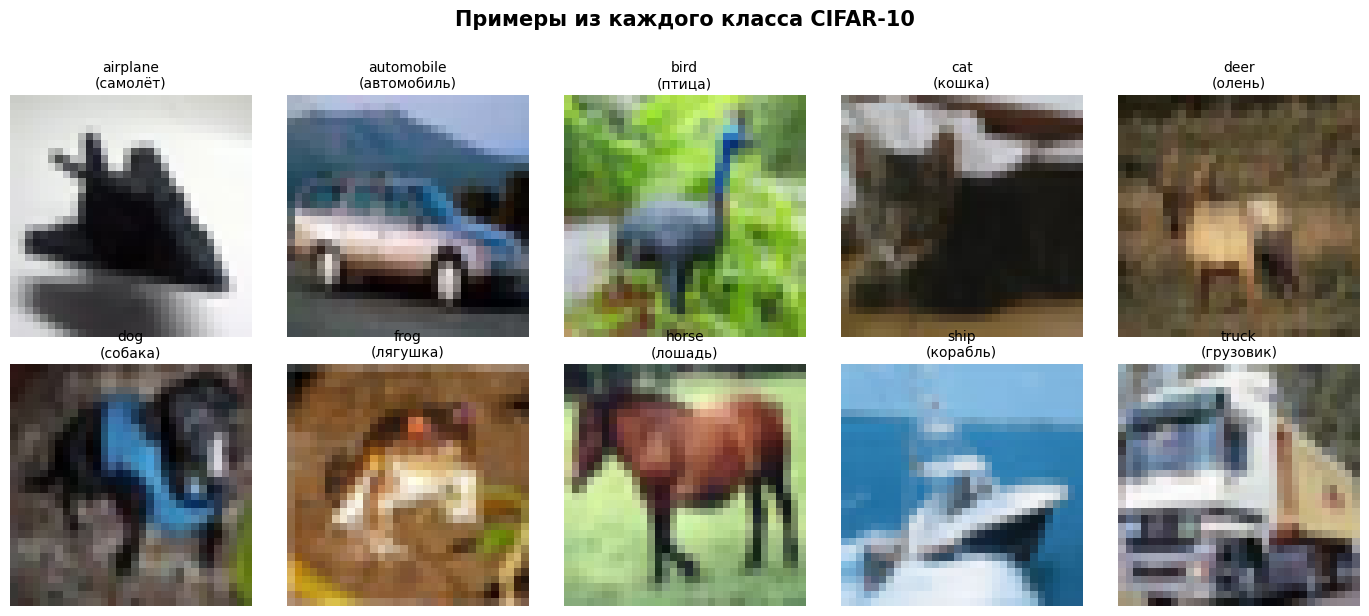

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Примеры из каждого класса CIFAR-10', fontsize=15, fontweight='bold', y=1.02)

for cls_idx in range(10):
    ax = axes[cls_idx // 5][cls_idx % 5]
    # Берём первое изображение данного класса
    idx = np.where(y_train_raw.flatten() == cls_idx)[0][0]
    ax.imshow(X_train_raw[idx])
    ax.set_title(f'{CLASS_NAMES_EN[cls_idx]}\n({CLASS_NAMES[cls_idx]})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

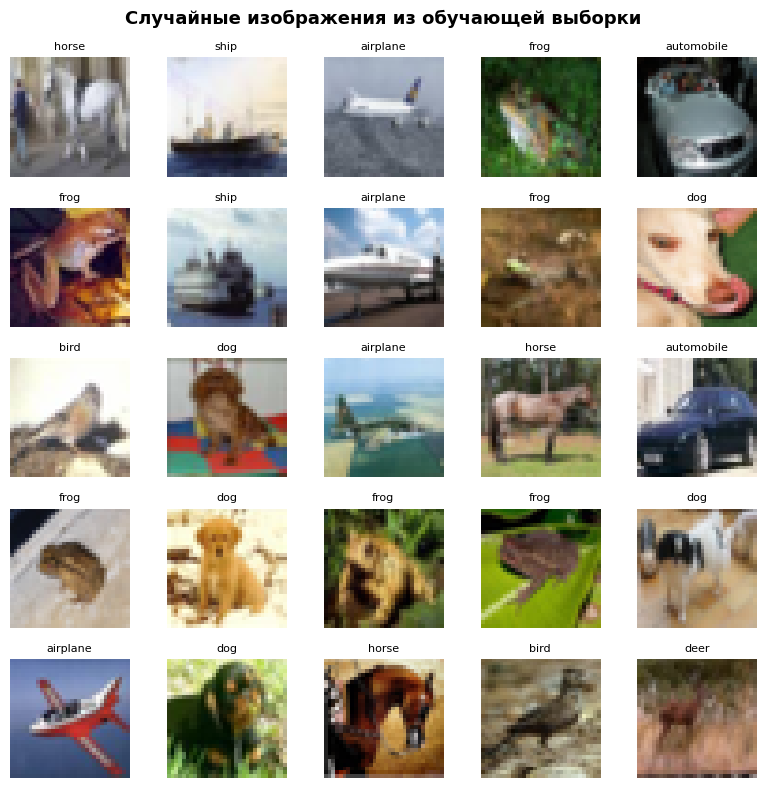

In [4]:
#  5×5 случайных изображений
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
fig.suptitle('Случайные изображения из обучающей выборки', fontsize=13, fontweight='bold')

indices = np.random.choice(len(X_train_raw), 25, replace=False)
for i, idx in enumerate(indices):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_train_raw[idx])
    ax.set_title(CLASS_NAMES_EN[y_train_raw[idx][0]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 4. Предобработка данных

In [5]:
# Нормализация: приводим пиксели из [0, 255] к [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

# One-hot кодирование меток классов
NUM_CLASSES = 10
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

## Вспомогательные функции

In [6]:
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Точность
    ax1.plot(epochs, history.history['accuracy'],     'b-o', markersize=4, label='Train')
    ax1.plot(epochs, history.history['val_accuracy'], 'r-o', markersize=4, label='Validation')
    ax1.set_title('Точность (Accuracy)')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # Потери
    ax2.plot(epochs, history.history['loss'],     'b-o', markersize=4, label='Train')
    ax2.plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Validation')
    ax2.set_title('Потери (Loss)')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, name=''):
    """Оценивает модель и возвращает словарь метрик."""
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'[{name}]  Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    return {'name': name, 'loss': loss, 'accuracy': acc}


# Словарь для хранения результатов всех моделей
results = {}
histories = {}

---
## Модель 1 

2 свёрточных блока + 1 Dense слой.  


In [7]:
def build_simple_cnn():
    model = models.Sequential([
        # Блок 1: свёртка + пулинг
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        # Блок 2: свёртка + пулинг
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Классификатор
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='Simple_CNN')
    return model

model1 = build_simple_cnn()
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

/Users/arseniy/envs/gpu_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-06 09:54:34.466677: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-06 09:54:34.466706: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-06 09:54:34.466713: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-06 09:54:34.466729: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 09:54:34.466754: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fact

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5895 - loss: 1.7795 - val_accuracy: 0.4574 - val_loss: 4.2877
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5585 - loss: 2.8001 - val_accuracy: 0.4634 - val_loss: 6.1761
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5301 - loss: 5.1340 - val_accuracy: 0.4238 - val_loss: 13.1459
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5084 - loss: 8.7475 - val_accuracy: 0.4226 - val_loss: 18.5456
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5078 - loss: 12.7075 - val_accuracy: 0.4348 - val_loss: 23.0286
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4851 - loss: 19.8460 - val_accuracy: 0.4272 - val_loss: 37.6167
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4743 - loss: 28.1862 - val_accuracy: 0.4150 - val_loss: 51.1326
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4645 - loss: 4

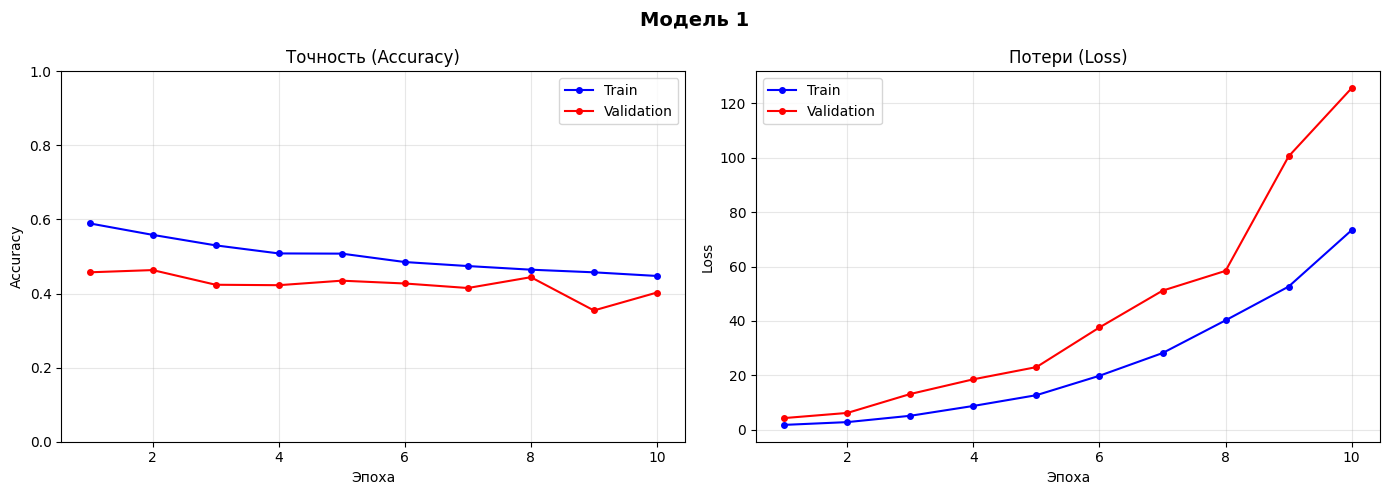

In [9]:
t0 = time.time()

history1 = model1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

t1 = time.time()
print(f'\nВремя обучения: {t1 - t0:.1f} сек.')
histories['Simple CNN'] = history1
results['Simple CNN'] = evaluate_model(model1, X_test, y_test, 'Simple CNN')
plot_history(history1, 'Модель 1')

---
## Модель 2 — с BatchNormalization и Dropout

больше свёрточных блоков, **BatchNormalization** для стабилизации обучения и **Dropout** для борьбы с переобучением.

In [10]:
def build_deep_cnn():
    model = models.Sequential([
        # Блок 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Блок 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Блок 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Классификатор
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='Deep_CNN_BN_Dropout')
    return model

model2 = build_deep_cnn()
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary()

Model: "Deep_CNN_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.4491 - loss: 1.6500 - val_accuracy: 0.5270 - val_loss: 1.3148 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6163 - loss: 1.0833 - val_accuracy: 0.6538 - val_loss: 0.9776 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6821 - loss: 0.9071 - val_accuracy: 0.6938 - val_loss: 0.8920 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7166 - loss: 0.8118 - val_accuracy: 0.7248 - val_loss: 0.7794 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7380 - loss: 0.7496 - val_accuracy: 0.7326 - val_loss: 0.7660 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7568 - loss: 0.6974 - val_accuracy: 0.7656 - val_loss: 0.6746 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7689 - l

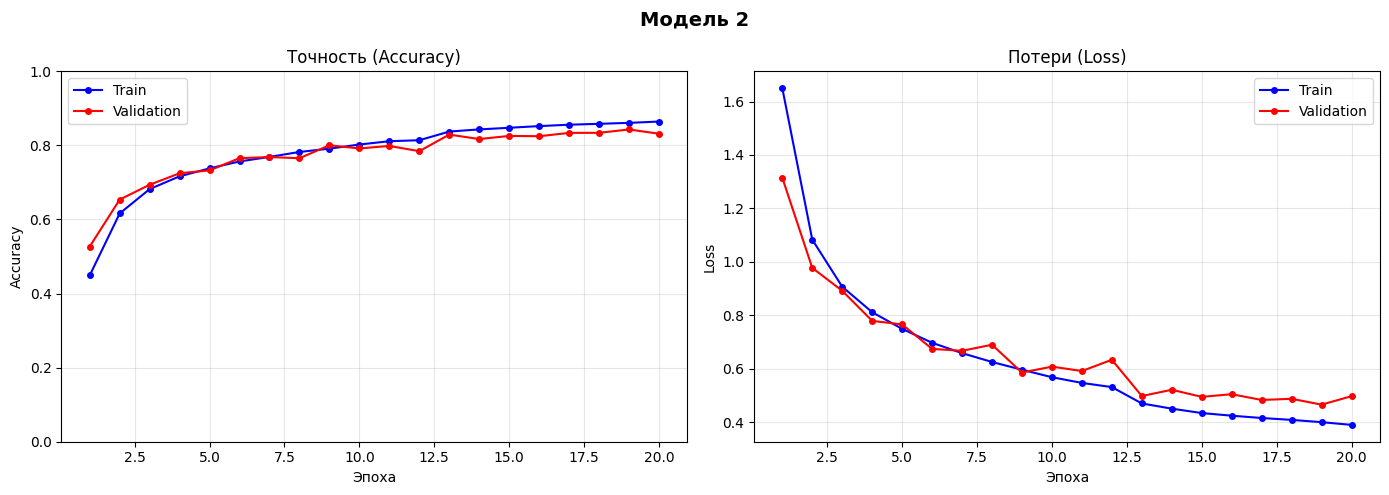

In [11]:
# Callbacks: ранняя остановка + снижение learning rate
callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()

history2 = model2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks2,
    verbose=1
)

t1 = time.time()
print(f'\nВремя обучения: {t1 - t0:.1f} сек.')
histories['Deep CNN'] = history2
results['Deep CNN'] = evaluate_model(model2, X_test, y_test, 'Deep CNN')
plot_history(history2, 'Модель 2')

---
## Модель 3 - с аугментацией данных

**Аугментация** — искусственное расширение датасета случайными преобразованиями изображений (поворот, сдвиг, отражение). Помогает бороться с переобучением.

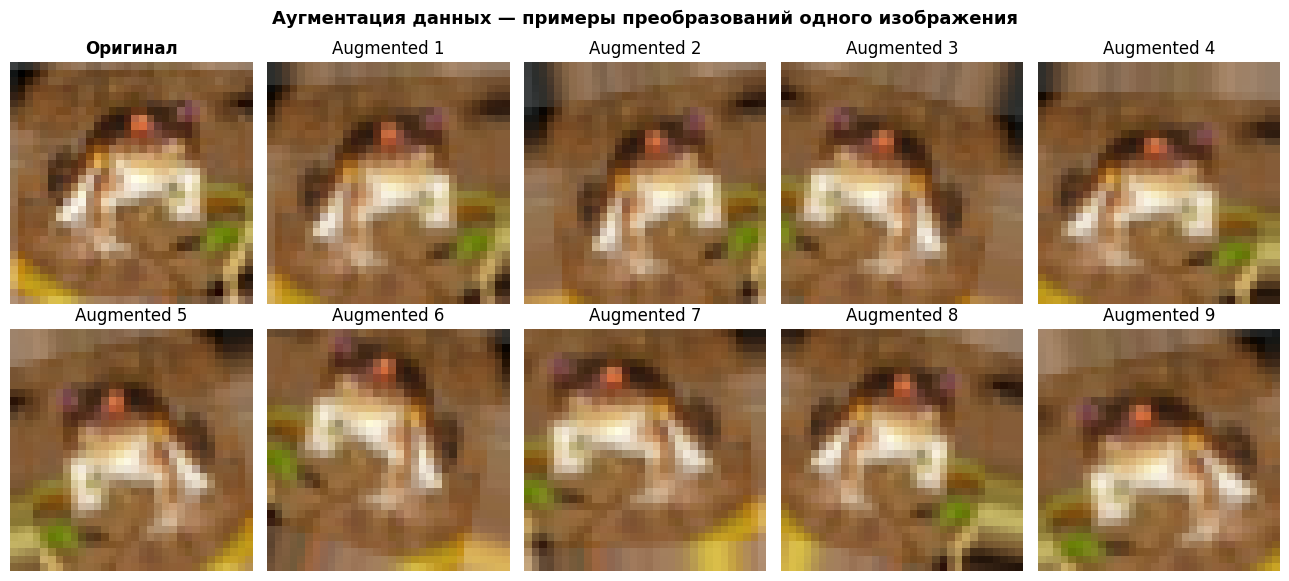

In [24]:
# Визуализация аугментации
datagen_preview = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

sample_img = X_train[0:1]
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle('Аугментация данных — примеры преобразований одного изображения', fontsize=13, fontweight='bold')

axes[0, 0].imshow(X_train[0])
axes[0, 0].set_title('Оригинал', fontweight='bold')
axes[0, 0].axis('off')

aug_iter = datagen_preview.flow(sample_img, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img)
    ax.set_title(f'Augmented {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/50


/Users/arseniy/envs/gpu_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


703/703 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.3873 - loss: 1.8195 - val_accuracy: 0.4834 - val_loss: 1.5259 - learning_rate: 0.0010
Epoch 2/50
  1/703 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.4688 - loss: 1.3123

/Users/arseniy/envs/gpu_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4688 - loss: 1.3123 - val_accuracy: 0.4774 - val_loss: 1.5487 - learning_rate: 0.0010
Epoch 3/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5371 - loss: 1.2953 - val_accuracy: 0.5376 - val_loss: 1.3263 - learning_rate: 0.0010
Epoch 4/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5156 - loss: 1.3309 - val_accuracy: 0.5392 - val_loss: 1.3277 - learning_rate: 0.0010
Epoch 5/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.6018 - loss: 1.1122 - val_accuracy: 0.6302 - val_loss: 1.0537 - learning_rate: 0.0010
Epoch 6/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7031 - loss: 1.0214 - val_accuracy: 0.6222 - val_loss: 1.0727 - learning_rate: 0.0010
Epoch 7/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.6425 - loss: 1.0078 - val_accuracy: 0.5400 - val_loss: 1.3759 - learning_rate: 0.0010
Epoch 8/50
703/703 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5938 - loss: 0.8792 - val_a

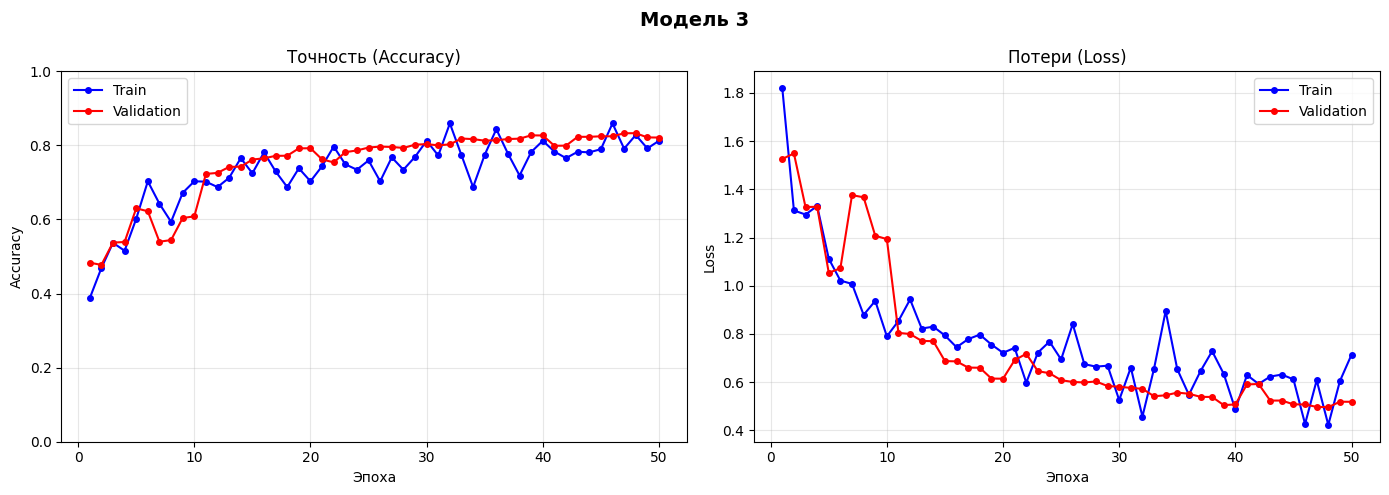

In [25]:
# Генератор аугментации для обучения
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Разделяем на train и validation
val_size = int(0.1 * len(X_train))
X_tr, X_val = X_train[val_size:], X_train[:val_size]
y_tr, y_val = y_train[val_size:], y_train[:val_size]

datagen.fit(X_tr)

def build_cnn_augmented():
    # Та же архитектура, но обучается на аугментированных данных.
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN_with_Augmentation')
    return model

model3 = build_cnn_augmented()
model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks3 = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

t0 = time.time()

history3 = model3.fit(
    datagen.flow(X_tr, y_tr, batch_size=64),
    steps_per_epoch=len(X_tr) // 64,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks3,
    verbose=1
)

t1 = time.time()
print(f'\nВремя обучения: {t1 - t0:.1f} сек.')
histories['CNN + Augmentation'] = history3
results['CNN + Augmentation'] = evaluate_model(model3, X_test, y_test, 'CNN + Augmentation')
plot_history(history3, 'Модель 3')

---
## Сравнение всех моделей

In [26]:
print('=' * 60)
print(f'{"Модель":<25} {"Test Loss":>12} {"Test Accuracy":>15}')
print('-' * 60)
for name, res in results.items():
    print(f'{name:<25} {res["loss"]:>12.4f} {res["accuracy"]*100:>14.2f}%')
print('=' * 60)

Модель                       Test Loss   Test Accuracy
------------------------------------------------------------
Simple CNN                    126.9391          39.89%
Deep CNN                        0.4954          83.37%
CNN + Augmentation              0.5398          81.56%


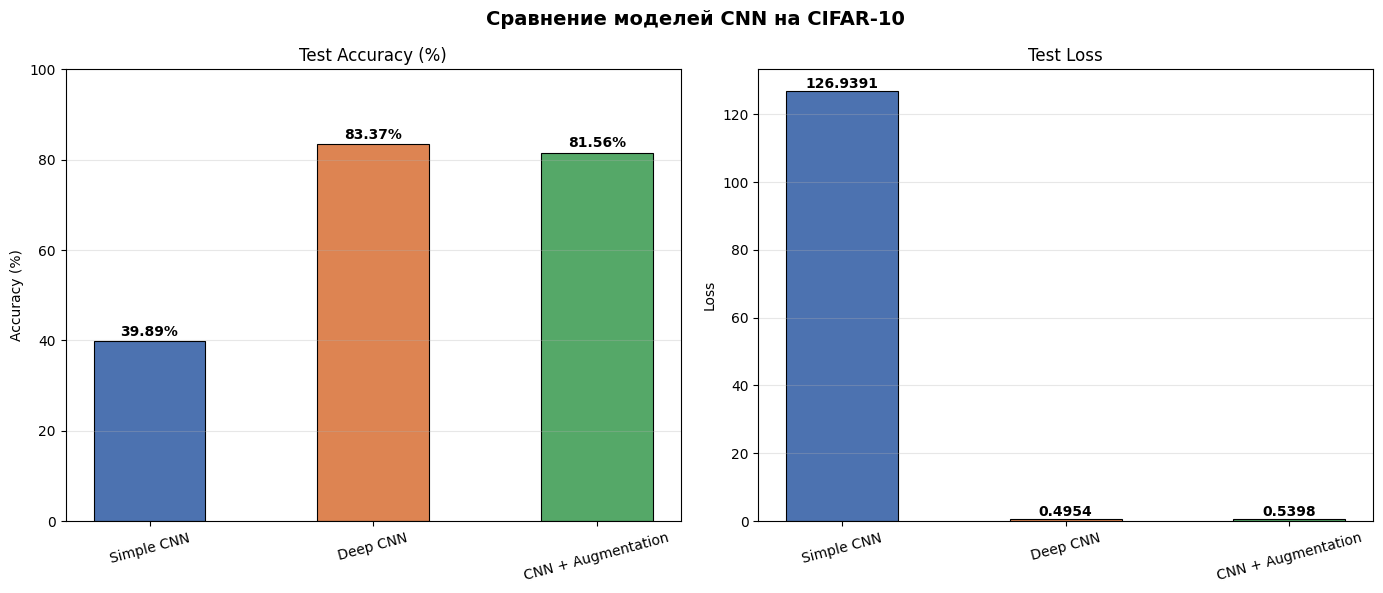

In [27]:
# График сравнения точности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Сравнение моделей CNN на CIFAR-10', fontsize=14, fontweight='bold')

names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in names]
losses = [results[n]['loss'] for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868']

# Точность
bars1 = axes[0].bar(names, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
axes[0].set_title('Test Accuracy (%)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Потери
bars2 = axes[1].bar(names, losses, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
axes[1].set_title('Test Loss', fontsize=12)
axes[1].set_ylabel('Loss')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

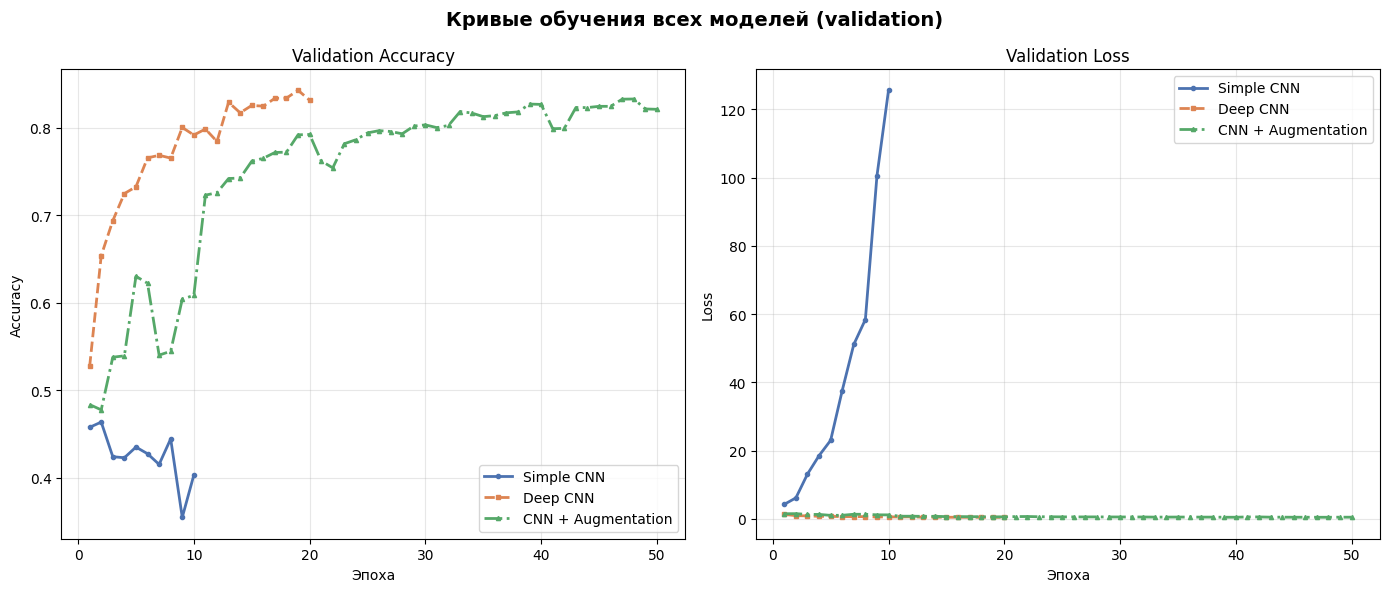

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Кривые обучения всех моделей (validation)', fontsize=14, fontweight='bold')

line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']
model_colors = ['#4C72B0', '#DD8452', '#55A868']

for (name, hist), ls, mk, col in zip(histories.items(), line_styles, markers, model_colors):
    epochs = range(1, len(hist.history['val_accuracy']) + 1)
    ax1.plot(epochs, hist.history['val_accuracy'], ls, marker=mk, markersize=3,
             color=col, label=name, linewidth=2)
    ax2.plot(epochs, hist.history['val_loss'], ls, marker=mk, markersize=3,
             color=col, label=name, linewidth=2)

ax1.set_title('Validation Accuracy')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Loss')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Анализ лучшей модели

In [29]:
# Выбираем лучшую модель
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model_map = {'Simple CNN': model1, 'Deep CNN': model2, 'CNN + Augmentation': model3}
best_model = best_model_map[best_name]
print(f'Лучшая модель: {best_name} ({results[best_name]["accuracy"]*100:.2f}%)')

Лучшая модель: Deep CNN (83.37%)


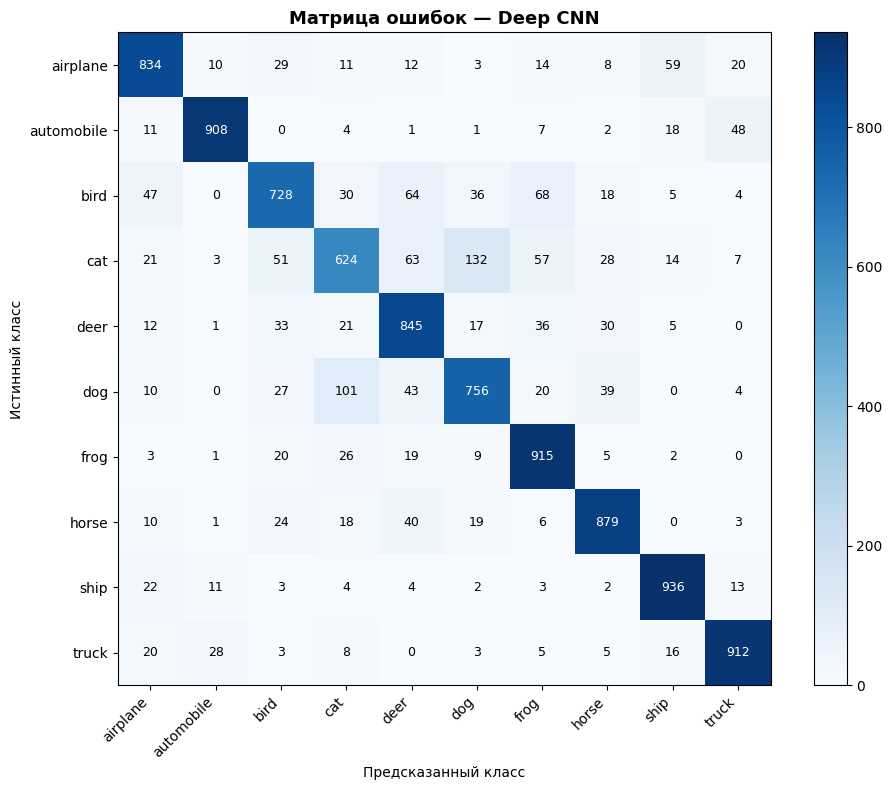

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Предсказания
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.argmax(y_test, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES_EN, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES_EN)
ax.set_title(f'Матрица ошибок — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black', fontsize=9)

plt.tight_layout()
plt.show()

In [31]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_EN))

              precision    recall  f1-score   support

    airplane       0.84      0.83      0.84      1000
  automobile       0.94      0.91      0.93      1000
        bird       0.79      0.73      0.76      1000
         cat       0.74      0.62      0.68      1000
        deer       0.77      0.84      0.81      1000
         dog       0.77      0.76      0.76      1000
        frog       0.81      0.92      0.86      1000
       horse       0.87      0.88      0.87      1000
        ship       0.89      0.94      0.91      1000
       truck       0.90      0.91      0.91      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



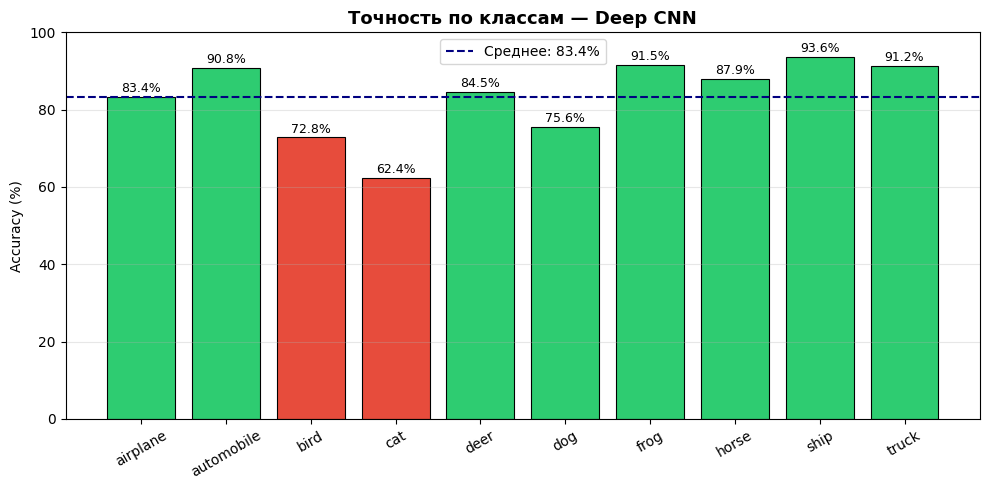

In [32]:
# Точность по каждому классу 
class_accuracies = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES_EN, class_accuracies * 100,
              color=['#2ecc71' if a >= 0.75 else '#e74c3c' for a in class_accuracies],
              edgecolor='black', linewidth=0.8)
ax.axhline(y=np.mean(class_accuracies)*100, color='navy', linestyle='--',
           linewidth=1.5, label=f'Среднее: {np.mean(class_accuracies)*100:.1f}%')
ax.set_title(f'Точность по классам — {best_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 100])
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, class_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

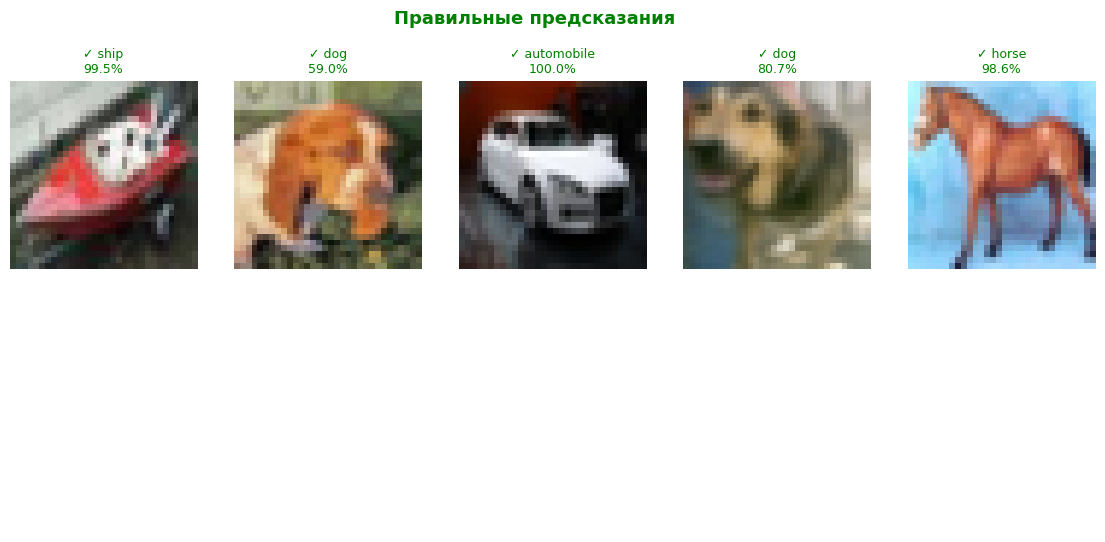

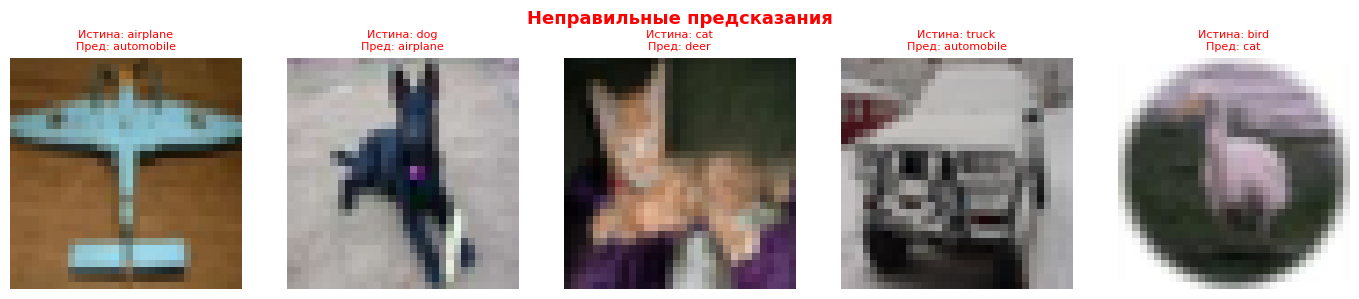

In [33]:
# Примеры правильных и неправильных предсказаний
correct_idx   = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Правильные предсказания', fontsize=13, fontweight='bold', color='green')
for i, idx in enumerate(np.random.choice(correct_idx, 5, replace=False)):
    for row in range(2):
        ax = axes[row][i]
        ax.axis('off')
    axes[0][i].imshow(X_test[idx])
    conf = y_pred_proba[idx][y_pred[idx]] * 100
    axes[0][i].set_title(f'✓ {CLASS_NAMES_EN[y_pred[idx]]}\n{conf:.1f}%', fontsize=9, color='green')

fig2, axes2 = plt.subplots(1, 5, figsize=(14, 3))
fig2.suptitle('Неправильные предсказания', fontsize=13, fontweight='bold', color='red')
for i, idx in enumerate(np.random.choice(incorrect_idx, 5, replace=False)):
    axes2[i].imshow(X_test[idx])
    axes2[i].set_title(
        f'Истина: {CLASS_NAMES_EN[y_true[idx]]}\nПред: {CLASS_NAMES_EN[y_pred[idx]]}',
        fontsize=8, color='red'
    )
    axes2[i].axis('off')

plt.tight_layout()
plt.show()

---
## 

Слой: conv2d_2
Форма карт признаков: (1, 32, 32, 32)  → 32 фильтров


/var/folders/br/nqfq1jl17g16l72vq9q9p0_00000gn/T/ipykernel_67833/1448150030.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


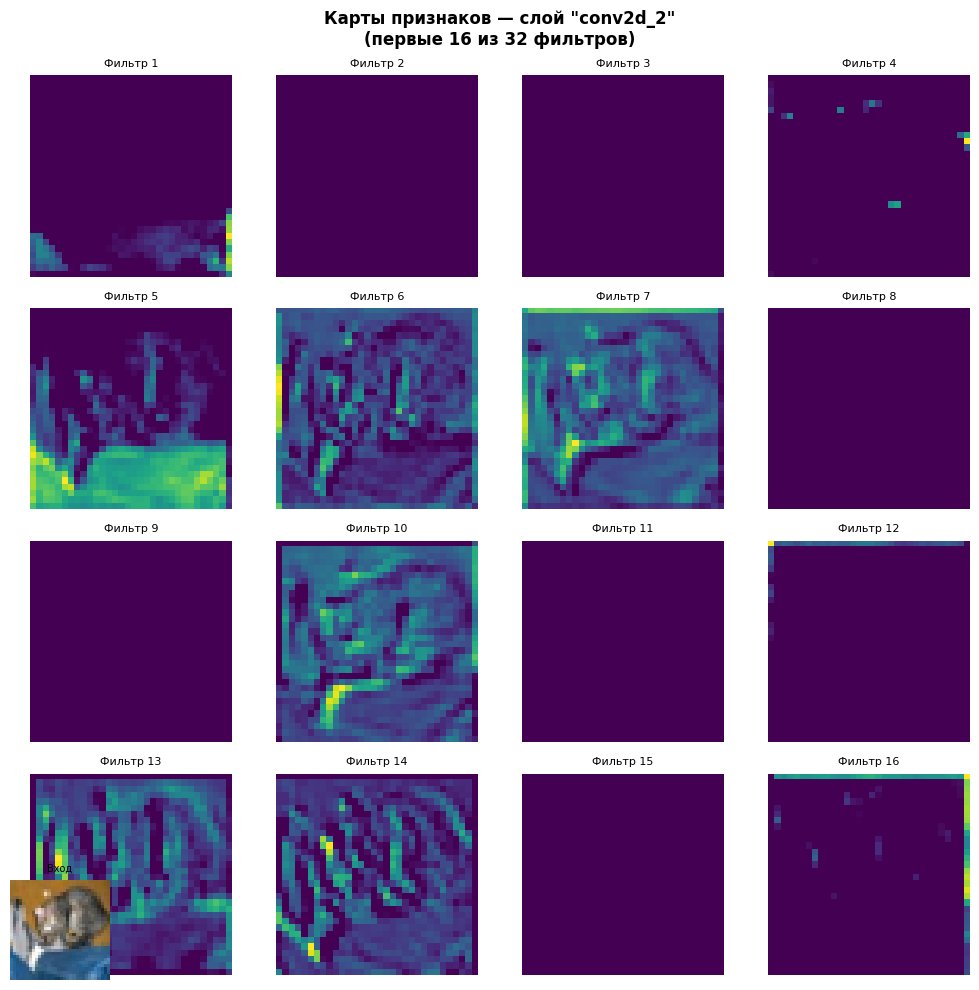

In [34]:
# Создаём модель-экстрактор признаков из первого Conv2D слоя лучшей модели
first_conv_layer = None
for layer in best_model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv_layer = layer
        break

feature_extractor = keras.Model(
    inputs=best_model.inputs,
    outputs=first_conv_layer.output
)

# Берём один пример
sample = X_test[0:1]
feature_maps = feature_extractor.predict(sample, verbose=0)

print(f'Слой: {first_conv_layer.name}')
print(f'Форма карт признаков: {feature_maps.shape}  → {feature_maps.shape[-1]} фильтров')

# Отображаем первые 16 карт признаков
n_filters = min(16, feature_maps.shape[-1])
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f'Карты признаков — слой "{first_conv_layer.name}"\n(первые {n_filters} из {feature_maps.shape[-1]} фильтров)',
             fontsize=12, fontweight='bold')

for i in range(n_filters):
    ax = axes[i // 4][i % 4]
    fmap = feature_maps[0, :, :, i]
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f'Фильтр {i+1}', fontsize=8)
    ax.axis('off')

# Вставляем исходное изображение
ax_orig = fig.add_axes([0.01, 0.01, 0.1, 0.1])
ax_orig.imshow(X_test[0])
ax_orig.set_title('Вход', fontsize=7)
ax_orig.axis('off')

plt.tight_layout()
plt.show()